## import

In [1]:
from tokenise import BPE_token
from pathlib import Path
import os
import pandas as pd
from os.path import join
import numpy as np
import torch
from tqdm.notebook import tqdm
from transformers import GPT2Config, GPT2LMHeadModel, GPT2Tokenizer
from transformers import  GPT2ForSequenceClassification

from torch.utils.data import Dataset, DataLoader

from ml_things import plot_dict, plot_confusion_matrix, fix_text
from sklearn.metrics import classification_report, accuracy_score
from transformers import (set_seed,
                          TrainingArguments,
                          Trainer,
                          GPT2Config,
                          GPT2Tokenizer,
                          AdamW,
                          get_linear_schedule_with_warmup,
                          GPT2ForSequenceClassification)

## generate corpus

In [ ]:
from right_corpus import NP, NPVP, SOV
print(len(NP + NPVP + SOV))

1092


In [3]:

df_ma = pd.read_excel('./MATERIAL.xlsx')
id_2_dur=dict(zip(df_ma['TrialID'],df_ma['soundDur']))


trail_list = [ str(df_ma['word1'][i]) + ' ' + str(df_ma['word2'][i]) + ' '  + str(df_ma['word3'][i]) + ' ' + str(df_ma['word4'][i]) + ' '   
              + str(df_ma['word5'][i]) + ' '   + str(df_ma['word6'][i]) + ' '   + str(df_ma['word7'][i]) + ' '   + str(df_ma['word8'][i])
               for i in range(len(df_ma))]
trail_list = [sentence.replace("nan", "").strip() for sentence in trail_list]


def remove_duplicates(sentence):
    words = sentence.split()  
    for i in range(7):
        if words[-1] ==words[-2]:
            words.pop(-1)
    return ' '.join(words)  


new_list = [remove_duplicates(sentence) for sentence in trail_list]

id_2_trail_type = dict(zip(list(df_ma['TrialID']),new_list))

new_new_list = []
for item in new_list:
    if item not in new_new_list:
        new_new_list.append(item)


new_list_co = []
new_list_unc = []
for co in new_list:
    if co in  NP + NPVP + SOV:
        new_list_co.append(co)
    else:
        new_list_unc.append(co)

new_list = new_list_co + new_list_unc

y_train = []
for itemt in new_list:
    if itemt in NP + NPVP + SOV:
        y_train.append('true')
    else:
        y_train.append('false')

## tokenizer

In [4]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the tokenizer
tokenizer = BPE_token()
## !!! need to train predcition model first
save_path = 'tokenized_data'
# Load the tokenizer
tokenizer = GPT2Tokenizer.from_pretrained(save_path)
tokenizer.add_special_tokens({
    "eos_token": "</s>",
    "bos_token": "<s>",
    "unk_token": "<unk>",
    "pad_token": "</s>",###</s>
    "mask_token": "<mask>"
})
tokenizer.padding_side='left' # because it's gpt

## hyperparameters

In [5]:
#hyperparams
layers = 2
#per_for_train = '10'
temp=1
lr = 5e-5
labels_ids = {'true': 0, 'false': 1}
n_labels = len(labels_ids)
max_length = 25
epochs = 200
batch_size = 16#16#36

## model config

In [6]:
# Create configuration
config = GPT2Config(
        vocab_size=tokenizer.vocab_size,
        bos_token_id=tokenizer.bos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        n_layer= layers,
        num_labels=n_labels,
    )

    # Create the model and move it to GPU
model = GPT2ForSequenceClassification(config).to(device)

    # Set the attention mask and pad token id
model.config.pad_token_id = tokenizer.eos_token_id

In [7]:
model

GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(79, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-1): 2 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=768, out_features=2, bias=False)
)

In [8]:
import random


random.seed(42)


assert len(new_list) == len(y_train)


num_elements = int(0.8 * len(new_list))


random_indices = random.sample(range(len(new_list)), num_elements)


remaining_indices = list(set(range(len(new_list))) - set(random_indices))


## dataset

### train dataset

In [9]:
class LearningWithFeedbackDataset(Dataset):
  r"""PyTorch Dataset class for loading data.

  This is where the data parsing happens.

  This class is built with reusability in mind: it can be used as is as.

  Arguments:

    path (:obj:`str`):
        Path to the data partition.

  """

  def __init__(self,use_tokenizer):

    self.texts = [new_list[i] for i in random_indices]
    self.labels = [y_train[i] for i in random_indices]
    
    # Number of exmaples.
    self.n_examples = len(self.labels)


    return

  def __len__(self):
    r"""When used `len` return the number of examples.

    """

    return self.n_examples

  def __getitem__(self, item):
    r"""Given an index return an example from the position.

    Arguments:

      item (:obj:`int`):
          Index position to pick an example to return.

    Returns:
      :obj:`Dict[str, str]`: Dictionary of inputs that contain text and
      asociated labels.

    """

    return {'text':self.texts[item],
            'label':self.labels[item]}


### test dataset

In [10]:
class test_LearningWithFeedbackDataset(Dataset):
  r"""PyTorch Dataset class for loading data.

  This is where the data parsing happens.

  This class is built with reusability in mind: it can be used as is as.

  Arguments:

    path (:obj:`str`):
        Path to the data partition.

  """

  def __init__(self,use_tokenizer):

    
    self.texts = [new_list[i] for i in remaining_indices]
    self.labels = [y_train[i] for i in remaining_indices]
    

    # Number of exmaples.
    self.n_examples = len(self.labels)


    return

  def __len__(self):
    r"""When used `len` return the number of examples.

    """

    return self.n_examples

  def __getitem__(self, item):
    r"""Given an index return an example from the position.

    Arguments:

      item (:obj:`int`):
          Index position to pick an example to return.

    Returns:
      :obj:`Dict[str, str]`: Dictionary of inputs that contain text and
      asociated labels.

    """

    return {'text':self.texts[item],
            'label':self.labels[item]}


### all_corpus

In [11]:
class all_corpus_LearningWithFeedbackDataset(Dataset):
  r"""PyTorch Dataset class for loading data.

  This is where the data parsing happens.

  This class is built with reusability in mind: it can be used as is as.

  Arguments:

    path (:obj:`str`):
        Path to the data partition.

  """

  def __init__(self,use_tokenizer):

    ALL_CORPUS = ( NP + NPVP + SOV)
    self.texts = ALL_CORPUS
    self.labels = ['true'] * len(ALL_CORPUS)
    

    # Number of exmaples.
    self.n_examples = len(self.labels)


    return

  def __len__(self):
    r"""When used `len` return the number of examples.

    """

    return self.n_examples

  def __getitem__(self, item):
    r"""Given an index return an example from the position.

    Arguments:

      item (:obj:`int`):
          Index position to pick an example to return.

    Returns:
      :obj:`Dict[str, str]`: Dictionary of inputs that contain text and
      asociated labels.

    """

    return {'text':self.texts[item],
            'label':self.labels[item]}


## data collator

In [12]:
class Gpt2ClassificationCollator(object):
    r"""
    Data Collator used for GPT2 in a classificaiton rask.

    It uses a given tokenizer and label encoder to convert any text and labels to numbers that
    can go straight into a GPT2 model.

    This class is built with reusability in mind: it can be used as is as long
    as the `dataloader` outputs a batch in dictionary format that can be passed
    straight into the model - `model(**batch)`.

    Arguments:

      use_tokenizer (:obj:`transformers.tokenization_?`):
          Transformer type tokenizer used to process raw text into numbers.

      labels_ids (:obj:`dict`):
          Dictionary to encode any labels names into numbers. Keys map to
          labels names and Values map to number associated to those labels.

      max_sequence_len (:obj:`int`, `optional`)
          Value to indicate the maximum desired sequence to truncate or pad text
          sequences. If no value is passed it will used maximum sequence size
          supported by the tokenizer and model.

    """

    def __init__(self, use_tokenizer, labels_encoder, max_sequence_len=None):

        # Tokenizer to be used inside the class.
        self.use_tokenizer = use_tokenizer
        # Check max sequence length.
        self.max_sequence_len = use_tokenizer.model_max_length if max_sequence_len is None else max_sequence_len
        # Label encoder used inside the class.
        self.labels_encoder = labels_encoder

        return

    def __call__(self, sequences):
        r"""
        This function allowes the class objesct to be used as a function call.
        Sine the PyTorch DataLoader needs a collator function, I can use this
        class as a function.

        Arguments:

          item (:obj:`list`):
              List of texts and labels.

        Returns:
          :obj:`Dict[str, object]`: Dictionary of inputs that feed into the model.
          It holddes the statement `model(**Returned Dictionary)`.
        """

        # Get all texts from sequences list.
        texts = [sequence['text'] for sequence in sequences]
        # Get all labels from sequences list.
        labels = [sequence['label'] for sequence in sequences]
        # Encode all labels using label encoder.
        labels = [self.labels_encoder[label] for label in labels]
        # Call tokenizer on all texts to convert into tensors of numbers with
        # appropriate padding.
        inputs = self.use_tokenizer(text=texts, return_tensors="pt", padding=True, truncation=True,  max_length=self.max_sequence_len)
        # Update the inputs with the associated encoded labels as tensor.
        inputs.update({'labels':torch.tensor(labels)})

        return inputs

## train function

In [13]:
def train(dataloader, optimizer_, scheduler_, device_):
  r"""
  Train pytorch model on a single pass through the data loader.

  It will use the global variable `model` which is the transformer model
  loaded on `_device` that we want to train on.

  This function is built with reusability in mind: it can be used as is as long
    as the `dataloader` outputs a batch in dictionary format that can be passed
    straight into the model - `model(**batch)`.

  Arguments:

      dataloader (:obj:`torch.utils.data.dataloader.DataLoader`):
          Parsed data into batches of tensors.

      optimizer_ (:obj:`transformers.optimization.AdamW`):
          Optimizer used for training.

      scheduler_ (:obj:`torch.optim.lr_scheduler.LambdaLR`):
          PyTorch scheduler.

      device_ (:obj:`torch.device`):
          Device used to load tensors before feeding to model.

  Returns:

      :obj:`List[List[int], List[int], float]`: List of [True Labels, Predicted
        Labels, Train Average Loss].
  """

  # Use global variable for model.
  global model

  # Tracking variables.
  predictions_labels = []
  true_labels = []
  # Total loss for this epoch.
  total_loss = 0

  # Put the model into training mode.
  model.train()

  # For each batch of training data...
  for batch in tqdm(dataloader, total=len(dataloader), disable=True):

    # Add original labels - use later for evaluation.
    true_labels += batch['labels'].numpy().flatten().tolist()

    # move batch to device
    batch = {k:v.type(torch.long).to(device_) for k,v in batch.items()}

    # Always clear any previously calculated gradients before performing a
    # backward pass.
    model.zero_grad()

    # Perform a forward pass (evaluate the model on this training batch).
    # This will return the loss (rather than the model output) because we
    # have provided the `labels`.
    # The documentation for this a bert model function is here:
    # https://huggingface.co/transformers/v2.2.0/model_doc/bert.html#transformers.BertForSequenceClassification
    outputs = model(**batch)

    # The call to `model` always returns a tuple, so we need to pull the
    # loss value out of the tuple along with the logits. We will use logits
    # later to calculate training accuracy.
    loss, logits = outputs[:2]

    # Accumulate the training loss over all of the batches so that we can
    # calculate the average loss at the end. `loss` is a Tensor containing a
    # single value; the `.item()` function just returns the Python value
    # from the tensor.
    total_loss += loss.item()

    # Perform a backward pass to calculate the gradients.
    loss.backward()

    # Clip the norm of the gradients to 1.0.
    # This is to help prevent the "exploding gradients" problem.
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # Update parameters and take a step using the computed gradient.
    # The optimizer dictates the "update rule"--how the parameters are
    # modified based on their gradients, the learning rate, etc.
    optimizer_.step()

    # Update the learning rate.
    scheduler_.step()

    # Move logits and labels to CPU
    logits = logits.detach().cpu().numpy()

    # Convert these logits to list of predicted labels values.
    predictions_labels += logits.argmax(axis=-1).flatten().tolist()

  # Calculate the average loss over the training data.
  avg_epoch_loss = total_loss / len(dataloader)

  # Return all true labels and prediction for future evaluations.
  return true_labels, predictions_labels, avg_epoch_loss

## test function

In [14]:
def validation(dataloader, device_):
    r"""
    Test pytorch model on a single pass through the data loader.

    It will use the global variable `model` which is the transformer model
    loaded on `device_` that we want to test on.

    This function is built with reusability in mind: it can be used as is as long
    as the `dataloader` outputs a batch in dictionary format that can be passed
    straight into the model - `model(**batch)`.

    Arguments:

        dataloader (:obj:`torch.utils.data.dataloader.DataLoader`):
            Parsed data into batches of tensors.

        device_ (:obj:`torch.device`):
            Device used to load tensors before feeding to model.

    Returns:

        :obj:`List[List[int], List[int], float]`: List of [True Labels, Predicted
        Labels, Test Average Loss].
    """

    # Use global variable for model.
    global model

    # Tracking variables.
    predictions_labels = []
    true_labels = []
    # Total loss for this epoch.
    total_loss = 0

    # Put the model into evaluation mode.
    model.eval()

    # Disable gradient computation.
    with torch.no_grad():
        # For each batch of test data...
        for batch in tqdm(dataloader, total=len(dataloader), disable=True):

            # Add original labels - use later for evaluation.
            true_labels += batch['labels'].numpy().flatten().tolist()

            # move batch to device
            batch = {k:v.type(torch.long).to(device_) for k,v in batch.items()}

            # Perform a forward pass (evaluate the model on this test batch).
            outputs = model(**batch)

            # The call to `model` always returns a tuple, so we need to pull the
            # loss value out of the tuple along with the logits. We will use logits
            # later to calculate test accuracy.
            loss, logits = outputs[:2]

            # Accumulate the test loss over all of the batches so that we can
            # calculate the average loss at the end. `loss` is a Tensor containing a
            # single value; the `.item()` function just returns the Python value
            # from the tensor.
            total_loss += loss.item()

            # Move logits and labels to CPU
            logits = logits.detach().cpu().numpy()

            # Convert these logits to list of predicted labels values.
            predictions_labels += logits.argmax(axis=-1).flatten().tolist()

    # Calculate the average loss over the test data.
    avg_epoch_loss = total_loss / len(dataloader)

    # Return all true labels and prediction for future evaluations.
    return true_labels, predictions_labels, avg_epoch_loss


## start training

## test and tain

In [15]:
# Create data collator to encode text and labels into numbers.
gpt2_classificaiton_collator = Gpt2ClassificationCollator(use_tokenizer=tokenizer,
                                                          labels_encoder=labels_ids,
                                                          max_sequence_len=max_length)


print('Dealing with Train...')
# Create pytorch dataset.
train_dataset = LearningWithFeedbackDataset(use_tokenizer=tokenizer)
print('Created `train_dataset` with %d examples!'%len(train_dataset))

# Move pytorch dataset into dataloader.
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=gpt2_classificaiton_collator)
print('Created `train_dataloader` with %d batches!'%len(train_dataloader))

print()

print('Dealing with Validation...')
# Create pytorch dataset.
valid_dataset = test_LearningWithFeedbackDataset(use_tokenizer=tokenizer)
print('Created `valid_dataset` with %d examples!'%len(valid_dataset))

# Move pytorch dataset into dataloader.
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=gpt2_classificaiton_collator)
print('Created `eval_dataloader` with %d batches!'%len(valid_dataloader))

Dealing with Train...
Created `train_dataset` with 230 examples!
Created `train_dataloader` with 15 batches!

Dealing with Validation...
Created `valid_dataset` with 58 examples!
Created `eval_dataloader` with 4 batches!


/home/nllsgyang/.conda/envs/gpt_brocanto/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch


  0%|          | 0/200 [00:00<?, ?it/s]


Training on batches...
Validation on batches...
  train_loss: 1.85838 - val_loss: 0.71452 - train_acc: 0.46087 - valid_acc: 0.53448


Training on batches...
Validation on batches...
  train_loss: 0.74164 - val_loss: 0.75687 - train_acc: 0.56087 - valid_acc: 0.55172


Training on batches...
Validation on batches...
  train_loss: 0.60647 - val_loss: 0.56204 - train_acc: 0.69130 - valid_acc: 0.68966


Training on batches...
Validation on batches...
  train_loss: 0.50918 - val_loss: 0.40014 - train_acc: 0.75217 - valid_acc: 0.81034


Training on batches...
Validation on batches...
  train_loss: 0.38017 - val_loss: 0.28246 - train_acc: 0.83913 - valid_acc: 0.86207


Training on batches...
Validation on batches...
  train_loss: 0.40735 - val_loss: 0.41630 - train_acc: 0.86087 - valid_acc: 0.82759


Training on batches...
Validation on batches...
  train_loss: 0.29524 - val_loss: 0.26277 - train_acc: 0.86522 - valid_acc: 0.87931


Training on batches...
Validation on batches...
  train_loss:

/home/nllsgyang/.conda/envs/gpt_brocanto/lib/python3.11/site-packages/ml_things/plot_functions.py:409: DeprecationWarning: `magnify` needs to have value in [0,1]! `1.2` will be converted to `0.1` as default.
  warnings.warn(f'`magnify` needs to have value in [0,1]! `{magnify}` will be converted to `0.1` as default.',


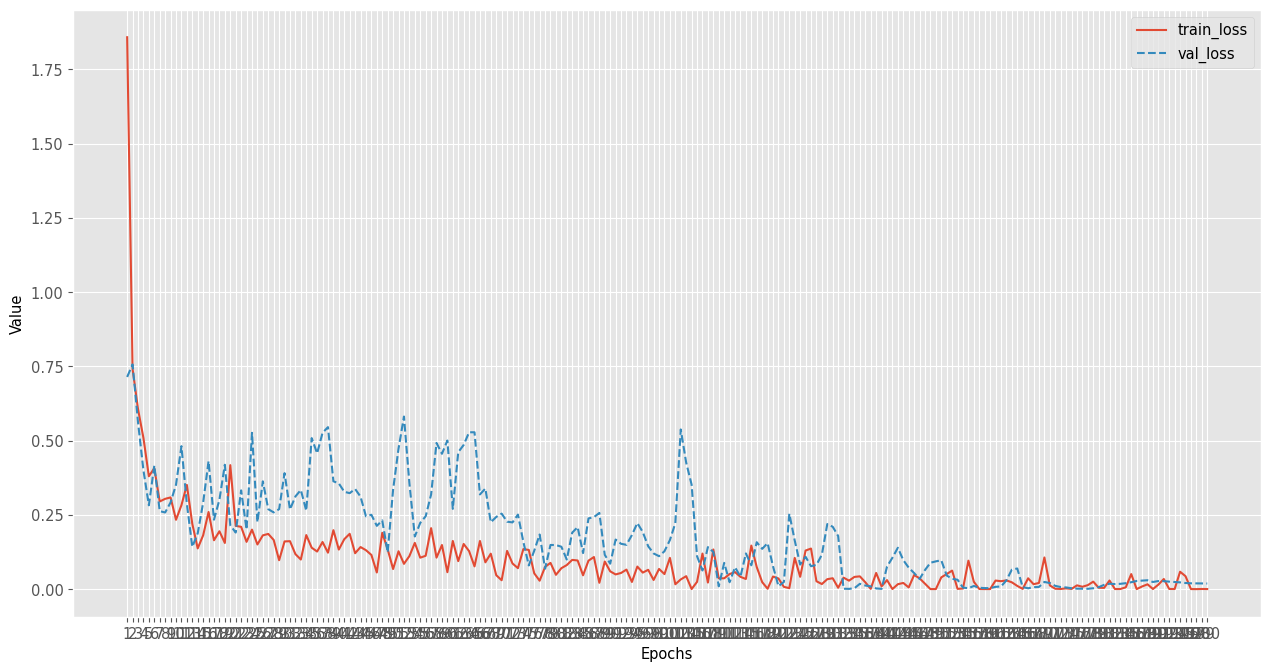

/home/nllsgyang/.conda/envs/gpt_brocanto/lib/python3.11/site-packages/ml_things/plot_functions.py:409: DeprecationWarning: `magnify` needs to have value in [0,1]! `1.2` will be converted to `0.1` as default.
  warnings.warn(f'`magnify` needs to have value in [0,1]! `{magnify}` will be converted to `0.1` as default.',


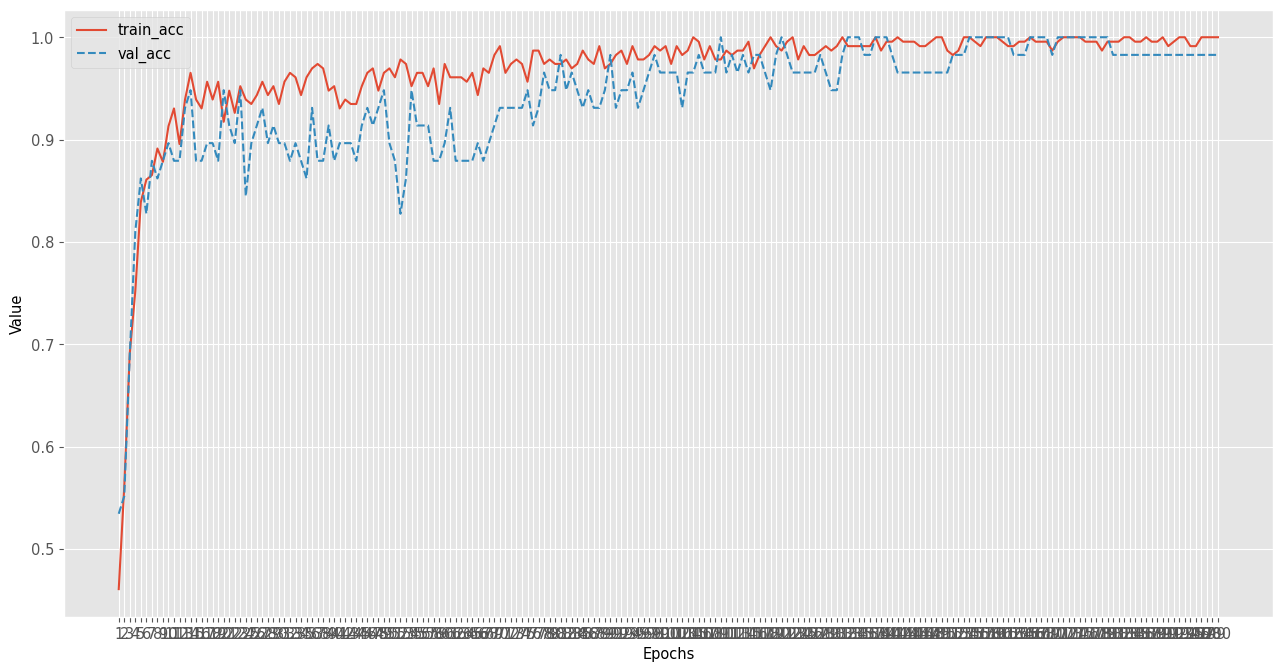

In [16]:
# Create configuration
config = GPT2Config(
        vocab_size=tokenizer.vocab_size,
        bos_token_id=tokenizer.bos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        n_layer= layers,
        num_labels=n_labels,
    )

    # Create the model and move it to GPU
model = GPT2ForSequenceClassification(config).to(device)

    # Set the attention mask and pad token id
model.config.pad_token_id = tokenizer.eos_token_id
# Note: AdamW is a class from the huggingface library (as opposed to pytorch)
# I believe the 'W' stands for 'Weight Decay fix"
optimizer = AdamW(model.parameters(),
                  lr = 5e-4, # default is 5e-5, our notebook had 2e-5
                  eps = 1e-8 # default is 1e-8.
                  )

# Total number of training steps is number of batches * number of epochs.
# `train_dataloader` contains batched data so `len(train_dataloader)` gives
# us the number of batches.
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = 0, # Default value in run_glue.py
                                            num_training_steps = total_steps)

# Store the average loss after each epoch so we can plot them.
all_loss = {'train_loss':[], 'val_loss':[]}
all_acc = {'train_acc':[], 'val_acc':[]}

# Loop through each epoch.
print('Epoch')
for epoch in tqdm(range(epochs)):
  print()
  print('Training on batches...')
  # Perform one full pass over the training set.
  train_labels, train_predict, train_loss = train(train_dataloader, optimizer, scheduler, device)
  train_acc = accuracy_score(train_labels, train_predict)

  # Get prediction form model on validation data.
  print('Validation on batches...')
  valid_labels, valid_predict, val_loss = validation(valid_dataloader, device)
  val_acc = accuracy_score(valid_labels, valid_predict)

  # Print loss and accuracy values to see how training evolves.
  print("  train_loss: %.5f - val_loss: %.5f - train_acc: %.5f - valid_acc: %.5f"%(train_loss, val_loss, train_acc, val_acc))
  print()

  # Store the loss value for plotting the learning curve.
  all_loss['train_loss'].append(train_loss)
  all_loss['val_loss'].append(val_loss)
  all_acc['train_acc'].append(train_acc)
  all_acc['val_acc'].append(val_acc)
  #if val_acc > highest_validation_acc:
  save_dir_model = './feedback_model/'
  os.makedirs(save_dir_model, exist_ok=True)
  output_dir = f"{save_dir_model}classification_epoch_{epoch}_val_acc_{val_acc}_model"
  #highest_accuracy = val_acc
  model.save_pretrained(output_dir)
# Plot loss curves.
plot_dict(all_loss, use_xlabel='Epochs', use_ylabel='Value', use_linestyles=['-', '--'])

# Plot accuracy curves.
plot_dict(all_acc, use_xlabel='Epochs', use_ylabel='Value', use_linestyles=['-', '--'])

## plot

In [17]:
cla_acc_list = []
cla_models_list = []
cla_models_path = './feedback_model'
for name_id in range(200):
    for name in os.listdir(cla_models_path):
        if name[0:3] == 'cla' and name.split('_')[2] == str(name_id) :#and (not (float(name.split('_')[5]) in cla_acc_list)):
            cla_models_list.append(cla_models_path+name)
            cla_acc_list.append(float(name.split('_')[5]))
        #break

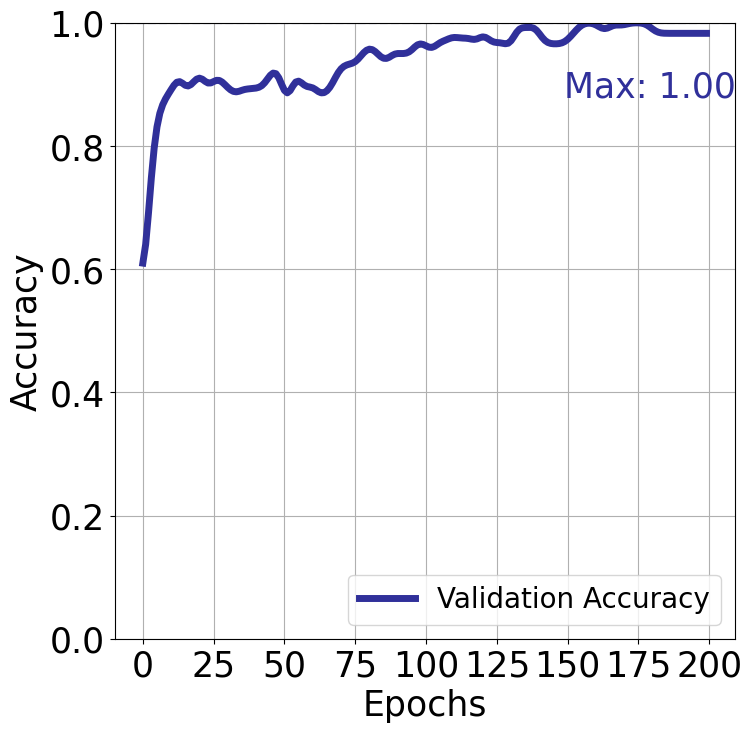

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d


#train_acc = all_acc['train_acc']
val_acc = cla_acc_list #all_acc['val_acc']


epochs = range(200)#range(1, len(train_acc) + 1)


plt.style.use('default')
plt.figure(figsize=(8, 8))


#train_acc_smooth = gaussian_filter1d(train_acc, sigma=3)
val_acc_smooth = gaussian_filter1d(val_acc, sigma=2)


plt.plot(epochs, val_acc_smooth, label='Validation Accuracy', color='#30309A', linestyle='-', linewidth=5)


max_val_y = max(val_acc_smooth)
max_val_x = epochs[list(val_acc_smooth).index(max_val_y)]  # 根据索引找到对应的 epoch


plt.axhline(y=max_val_y, color='#30309A', linestyle='--', linewidth=1.5, alpha=0.8)


max_val_y = 1.00
plt.text(max_val_x + 5, max_val_y-0.12, f'Max: {max_val_y:.2f}', 
         fontsize=25, color='#30309A', ha='center')

plt.xticks(fontsize=25) 
plt.yticks(fontsize=25)
plt.ylim(0, 1.0)  # Set y-axis limit from 0 to 1.0
plt.xlabel('Epochs', fontsize=25)
plt.ylabel('Accuracy', fontsize=25)
plt.grid(True)
plt.legend(loc='lower right', fontsize=20)


plt.show()
